# The global mean is just a mean

On a regular lon/lat grid, averaging a field over the globe is a small trap
with a well known fix: cells near the poles are narrow, so you weight by the
cosine of latitude before you average. Forget it and your global mean
temperature comes out several kelvin too cold, because you counted the
Arctic as though it were as large as the tropics.

HEALPix removes the trap rather than fixing it. Every cell on the sphere has
exactly the same area, at every level, everywhere. The weights are all
equal, so the area weighted mean and the arithmetic mean are the same number
and there is nothing to remember.

*The figure is saved with this notebook. Run the cells in order, from the top, to compute it again. The same example on the web: [The global mean is just a mean](https://waterpark.dkrz.de/docs/examples/02_global_mean/).*

## Forty years of monthly means

This one reads hundreds of time steps rather than one map, so it uses the
coarse end of the pyramid. A global mean has no spatial detail left in it
by definition, and level 4 gives the same answer as level 8 to well inside
the line width.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

URL = "s3://reanalysis/healpix/era5/P1M/level_4.zarr"
S3 = {"anon": True, "endpoint_url": "https://s3.waterpark.dkrz.de"}

ds = xr.open_zarr(URL, storage_options=S3, chunks=None)
field = ds["tas"].sel(time=slice("1980", "2024"))

print(f"{field.sizes['time']} months x {field.sizes['cell']} cells")
print(f"{field.nbytes / 1e6:.0f} MB")

## The average

That is the whole calculation. No weights, no `cos(lat)`, no cell area
array to look up or carry around.

In [ ]:
global_mean = field.mean("cell").load()

## Checking it against the wrong answer

It is worth seeing what the reflex costs here. Applying cosine weights to
a grid that is already equal area does not leave the answer alone: it
tilts the average towards the equator, and the resulting bias is far
larger than any signal you would be looking for.

In [ ]:
cos_weights = xr.DataArray(
    np.cos(np.deg2rad(ds["latitude"].values)), dims="cell"
)
wrongly_weighted = field.weighted(cos_weights).mean("cell").load()

offset = float((wrongly_weighted - global_mean).mean())
print(f"cosine weighting shifts the global mean by {offset:+.2f} K")

## One weighting you do still need

Equal area settles space. It says nothing about time, and months are not
the same length. An annual mean built from monthly means has to weight by
the number of days in each month, or February counts as much as January.

The error is small, a few hundredths of a kelvin, which is precisely what
makes it dangerous: it is invisible in a plot and the same size as the
trends people fit to these series.

In [ ]:
days = field["time"].dt.days_in_month
annual = (
    (global_mean * days).groupby("time.year").sum()
    / days.groupby("time.year").sum()
)
annual_unweighted = global_mean.groupby("time.year").mean()

print(f"largest difference between the two annual means: "
      f"{float(abs(annual - annual_unweighted).max()):.3f} K")

## The plot

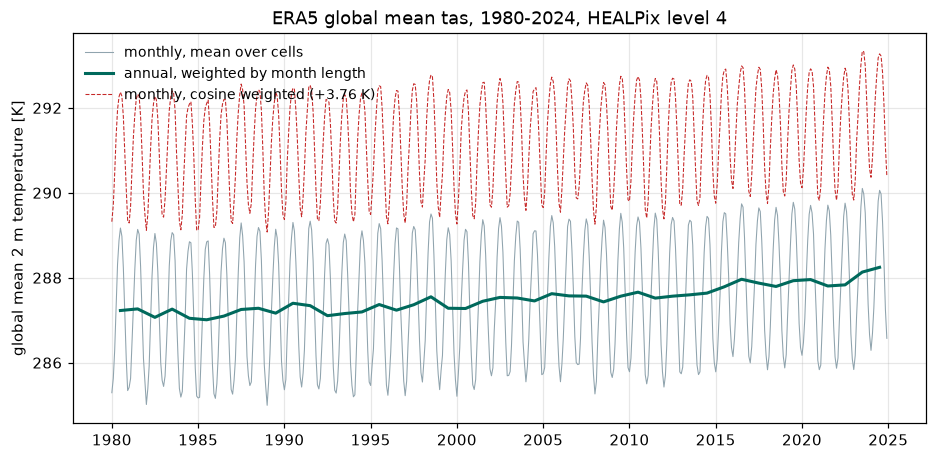

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.6))

ax.plot(global_mean.time, global_mean, color="#90a4ae", lw=0.7,
        label="monthly, mean over cells")
ax.plot(
    [np.datetime64(f"{y}-07-01") for y in annual.year.values], annual,
    color="#00695c", lw=2.0, label="annual, weighted by month length",
)
ax.plot(global_mean.time, wrongly_weighted, color="#c62828", lw=0.7, ls="--",
        label=f"monthly, cosine weighted ({offset:+.2f} K)")

ax.set_ylabel("global mean 2 m temperature [K]")
ax.set_title("ERA5 global mean tas, 1980-2024, HEALPix level 4")
ax.grid(alpha=0.3)
ax.legend(frameon=False, loc="upper left", fontsize=9)

fig.savefig("02_global_mean.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

## What equal area buys you

It is not only a convenience for global means. It is what makes an average
over an arbitrary set of cells correct without weights, what makes a zonal
mean over a ring correct without weights, and what makes coarsening the
pyramid a plain average of four numbers rather than an area weighted sum.
Several later examples are one line long for this reason alone.